🚀 算力怪兽：宏观千阶绝对锚定 (1D vs 2D vs GUE 终极消融正负趋势版)
ERROR! Session/line number was not unique in database. History logging moved to new session 264
[*] 正在启动 Jupyter 线程池 (任务数: 3)...
[M-GUE: Gaussian Unitary Ensemble (Global Scaling)] GUE 随机矩阵生成完成，耗时: 1.1s, 正在求解厄米特征值...
[M-GUE: Gaussian Unitary Ensemble (Global Scaling)] 提取完毕! 对齐: 1000 阶 | Global Scaling Scale=22.9871 | MSE=7006.05
[M1: 1D Single-Point (k1=13.86875246184216)] 稠密积分完成，耗时: 328.4s, 正在转入暴力特征值求解...
[M2: 2D Single-Point (k1=12.780681088052264, k2=2.606694575980814)] 稠密积分完成，耗时: 350.0s, 正在转入暴力特征值求解...
[M1: 1D Single-Point (k1=13.86875246184216)] 提取完毕! 对齐: 1000 阶 | Single-Point Scale=1021.3317 | MSE=2281.04
[M2: 2D Single-Point (k1=12.780681088052264, k2=2.606694575980814)] 提取完毕! 对齐: 1000 阶 | Single-Point Scale=1040.6954 | MSE=1515.27

[+] 宏观千阶消融大图(GUE全局缩放版)已保存为 macroscopic_1000_ablation_gue_global_scaled.png！


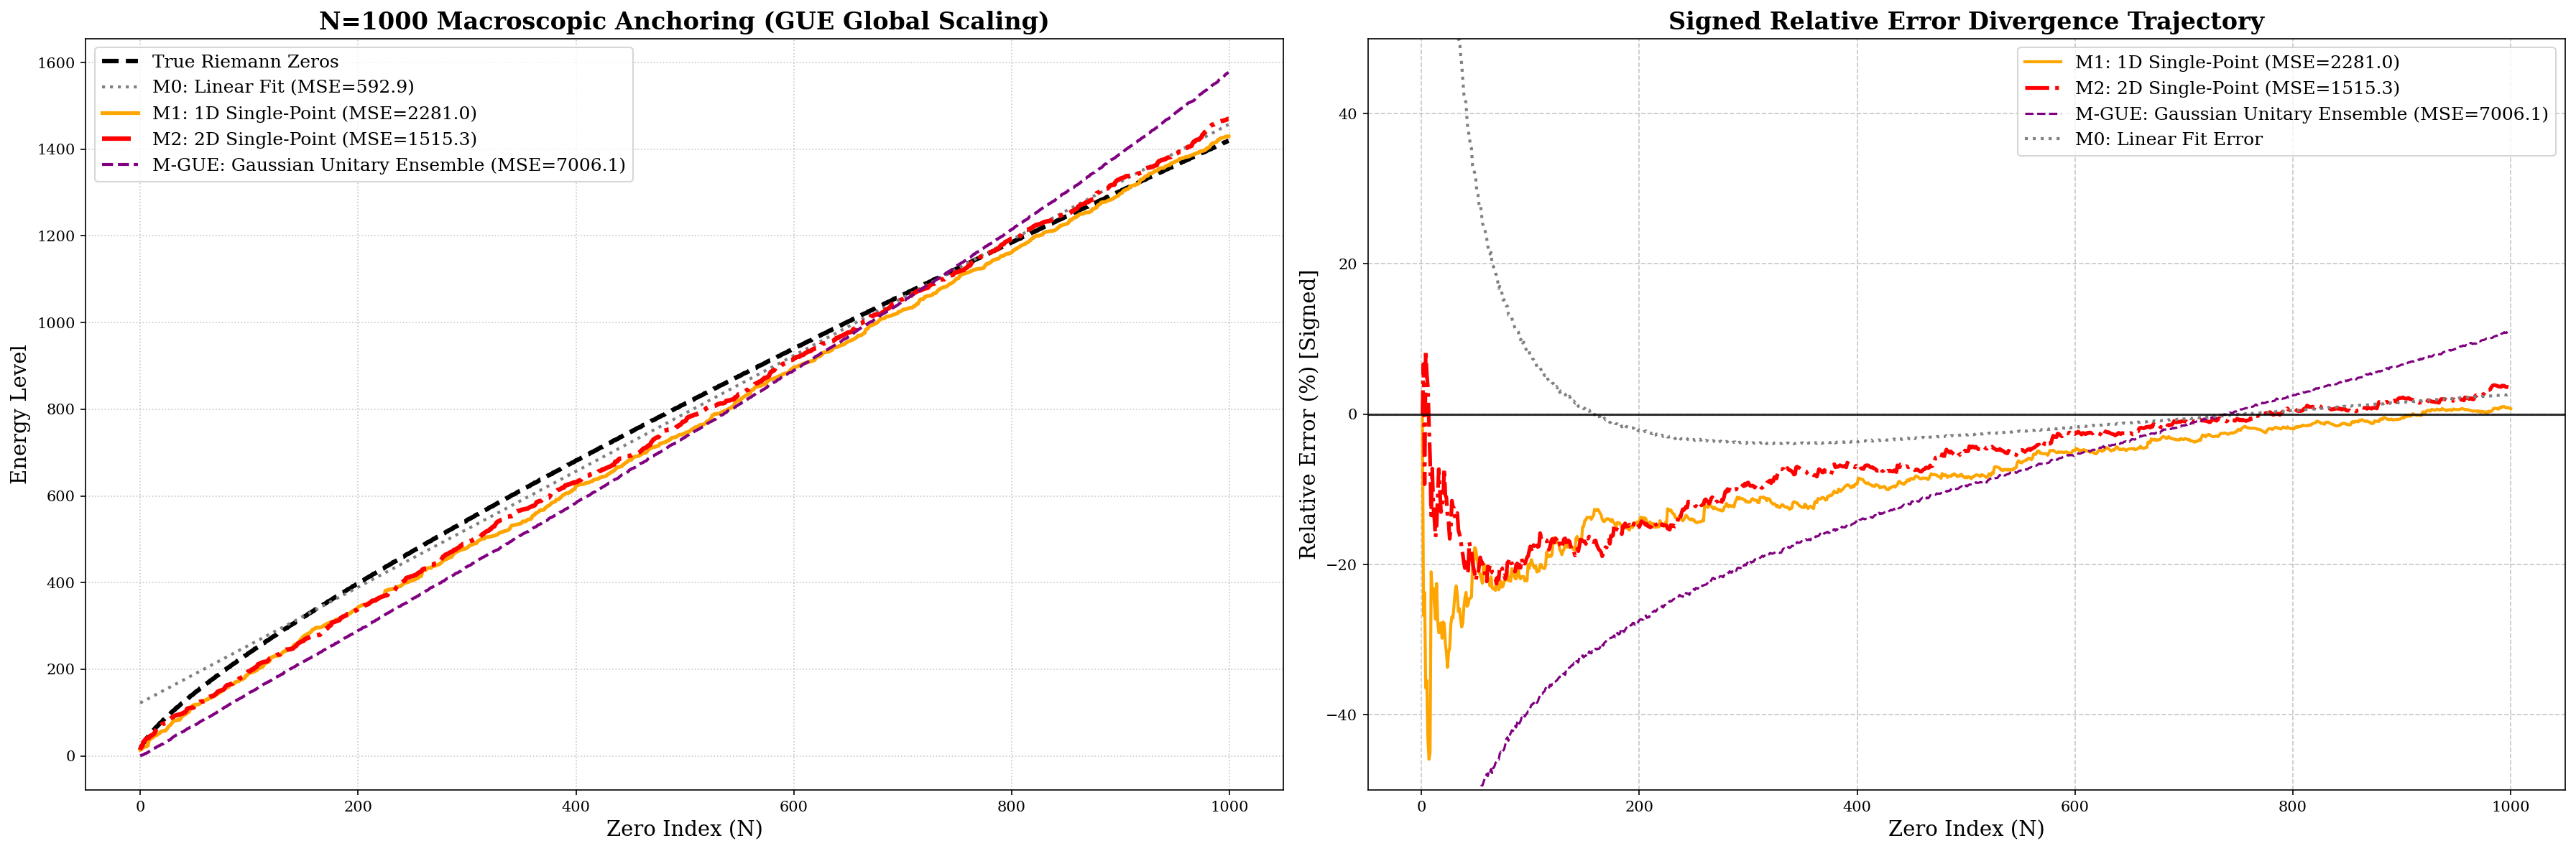

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
from numba import njit
import time
import concurrent.futures

print("="*95)
print("🚀 算力怪兽：宏观千阶绝对锚定 (1D vs 2D vs GUE 终极消融正负趋势版)")
print("="*95)

# ================= 1. 准备真实的黎曼零点 (1000个) =================
N_compare = 1000
mpmath.mp.dps = 25
true_zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_compare + 1)])

u_c_target = 1.543689
steps_global = 10_000_000_000  # 100 亿步
offset_global = 100000.0
n_bins_global = 10000          # 1万网格分辨率！

# ================= 2. 绝对精度隔离的动力学内核 (1D & 2D) =================
@njit(fastmath=True, nogil=True)
def kernel_1d(u_temp, k1, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1 / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1 / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: 
            counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

@njit(fastmath=True, nogil=True)
def kernel_2d(u_temp, k1, k2, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1/(L_i**2) + k2/(L_i**3)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1/(L_i**2) + k2/(L_i**3)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: 
            counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

# ================= 3. 线程 Worker =================
def worker_task(task_info):
    name, model_type, params = task_info
    t0 = time.time()
    L_end = np.log(steps_global + offset_global)
    
    if model_type == '1D':
        k1 = params[0]
        u_temp = u_c_target - k1 / (L_end**2)
        counts = kernel_1d(u_temp, k1, steps_global, n_bins_global, offset_global)
        print(f"[{name}] 稠密积分完成，耗时: {time.time()-t0:.1f}s, 正在转入暴力特征值求解...")
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        P = counts / row_sums
        vals = np.linalg.eigvals(P)
        valid_mask = (vals.imag > 1e-5)
        sim_pos = np.unwrap(np.sort(np.angle(vals[valid_mask])))
        
    elif model_type == '2D':
        k1, k2 = params
        u_temp = u_c_target - k1/(L_end**2) - k2/(L_end**3)
        counts = kernel_2d(u_temp, k1, k2, steps_global, n_bins_global, offset_global)
        print(f"[{name}] 稠密积分完成，耗时: {time.time()-t0:.1f}s, 正在转入暴力特征值求解...")
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        P = counts / row_sums
        vals = np.linalg.eigvals(P)
        valid_mask = (vals.imag > 1e-5)
        sim_pos = np.unwrap(np.sort(np.angle(vals[valid_mask])))
        
    elif model_type == 'RMT':
        N_dim = 2500 
        np.random.seed(42)
        A = np.random.randn(N_dim, N_dim) + 1j * np.random.randn(N_dim, N_dim)
        H_gue = (A + A.conj().T) / 2.0 
        print(f"[{name}] GUE 随机矩阵生成完成，耗时: {time.time()-t0:.1f}s, 正在求解厄米特征值...")
        vals = np.linalg.eigvalsh(H_gue)
        sim_pos = np.sort(vals[vals > 0])
        sim_pos = sim_pos - sim_pos[0] + 0.01 
        
    N_actual = min(len(sim_pos), len(true_zeros))
    sim_pos = sim_pos[:N_actual]
    tz_pos = true_zeros[:N_actual]
    
    # 🌟 锚定策略分化：1D/2D 用单点极限考验，GUE 用全局最小二乘保底
    if model_type == 'RMT':
        # 💡 GUE 全局最小二乘缩放 (Forced Origin, b=0)
        scale = np.dot(sim_pos, tz_pos) / np.dot(sim_pos, sim_pos)
        anchor_type = "Global Scaling"
    else:
        # 🌟 1D/2D 绝对单点锚定
        scale = tz_pos[0] / sim_pos[0]
        anchor_type = "Single-Point"
        
    calib = scale * sim_pos
        
    # 🔥 保留正负漂移趋势！
    rel_err_signed = (calib - tz_pos) / tz_pos * 100
    mse = np.mean((calib - tz_pos)**2)
    
    print(f"[{name}] 提取完毕! 对齐: {N_actual} 阶 | {anchor_type} Scale={scale:.4f} | MSE={mse:.2f}")
    
    pad_width = N_compare - N_actual
    full_calib = np.pad(calib, (0, pad_width), constant_values=np.nan)
    full_err_signed = np.pad(rel_err_signed, (0, pad_width), constant_values=np.nan)
    return name, full_calib, full_err_signed, mse

# ================= 4. 主程序：并发联合作战 =================
if __name__ == "__main__":
    
    n_indices = np.arange(1, N_compare + 1)
    slope, intercept = np.polyfit(n_indices, true_zeros, 1)
    calib_lin = slope * n_indices + intercept
    err_lin_signed = (calib_lin - true_zeros) / true_zeros * 100
    mse_lin = np.mean((calib_lin - true_zeros)**2)

    tasks = [
        ("M1: 1D Single-Point (k1=13.86875246184216)", '1D', [13.86875246184216]),
        ("M2: 2D Single-Point (k1=12.780681088052264, k2=2.606694575980814)", '2D', [12.780681088052264, 12.606694575980814]),
        ("M-GUE: Gaussian Unitary Ensemble (Global Scaling)", 'RMT', []) 
    ]
    
    print(f"[*] 正在启动 Jupyter 线程池 (任务数: {len(tasks)})...")
    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        results = list(executor.map(worker_task, tasks))
        
    # ================= 5. 封神绘图 =================
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    fig, axes = plt.subplots(1, 2, figsize=(24, 8), dpi=150)
    
    axes[0].plot(true_zeros, 'k--', linewidth=3, label='True Riemann Zeros')
    axes[0].plot(calib_lin, color='gray', linestyle=':', linewidth=2, label=f'M0: Linear Fit (MSE={mse_lin:.1f})')
    
    styles = [
        {'color': 'orange', 'linestyle': '-', 'linewidth': 2.5},   # 1D
        {'color': 'red', 'linestyle': '-.', 'linewidth': 3.0},     # 2D
        {'color': 'purple', 'linestyle': '--', 'linewidth': 2.0}   # GUE
    ]
    
    for i, res in enumerate(results):
        name, calib, err_signed, mse = res
        style = styles[i]
        # 让标题更短一点放进图例
        short_name = name.split('(')[0].strip()
        label_str = f"{short_name} (MSE={mse:.1f})"
        
        axes[0].plot(calib, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'], label=label_str)
        axes[1].plot(np.arange(1, N_compare + 1), err_signed, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth']-0.5, label=label_str)

    axes[1].plot(np.arange(1, N_compare + 1), err_lin_signed, color='gray', linestyle=':', linewidth=2, label=f'M0: Linear Fit Error')

    axes[0].set_title("N=1000 Macroscopic Anchoring (GUE Global Scaling)", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("Zero Index (N)", fontsize=14)
    axes[0].set_ylabel("Energy Level", fontsize=14)
    axes[0].legend(loc='upper left', fontsize=12)
    axes[0].grid(True, linestyle=':', alpha=0.7)

    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    axes[1].set_title("Signed Relative Error Divergence Trajectory", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("Zero Index (N)", fontsize=14)
    axes[1].set_ylabel("Relative Error (%) [Signed]", fontsize=14)
    axes[1].legend(loc='upper right', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # 动态截取 Y 轴，这次 GUE 稍微乖一点了，可能不用切得那么狠
    max_err_amp = max(np.nanmax(np.abs(results[0][2])), np.nanmax(np.abs(results[1][2])))
    y_limit = min(max_err_amp * 2.0, 50.0) 
    axes[1].set_ylim(-y_limit, y_limit) 

    plt.tight_layout()
    plt.savefig("macroscopic_1000_ablation_gue_global_scaled.png")
    print("\n[+] 宏观千阶消融大图(GUE全局缩放版)已保存为 macroscopic_1000_ablation_gue_global_scaled.png！")
    plt.show()